In [122]:
import casadi as ca
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2
from matplotlib.patches import Ellipse
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import sys, os
sys.path.append(os.path.abspath('..'))
from se2 import se2_exp, se2_log

In [123]:
def ES_EKF():
    # Initialize variables
    x_nom           = ca.SX.sym("x_nom", 3)
    P         = ca.SX.sym("P", 3, 3)
    v         = ca.SX.sym("v")
    w         = ca.SX.sym("w")
    dt        = ca.SX.sym("dt")
    sigma_v   = ca.SX.sym("sigma_v")
    sigma_w   = ca.SX.sym("sigma_w")
    sigma_gps = ca.SX.sym("sigma_gps")
    z_gps     = ca.SX.sym("z_gps", 2)
    gps_flag  = ca.SX.sym("gps_flag")

    A_error = ca.vertcat(
    ca.horzcat( 1,      w*dt,  0     ),
    ca.horzcat(-w*dt,   1,     v*dt  ),
    ca.horzcat( 0,      0,     1     )
    )
    H = ca.vertcat(
    ca.horzcat(ca.cos(x_nom[2]), -ca.sin(x_nom[2]), 0),
    ca.horzcat(ca.sin(x_nom[2]),  ca.cos(x_nom[2]), 0)
    )
    Q_body = ca.diag(ca.vertcat(sigma_v**2, 0, sigma_w**2))
    Q_gps = ca.diag(ca.vertcat(sigma_gps**2, sigma_gps**2))

    # Propagate state
    x_prop = ca.vertcat(x_nom[0] + v*ca.cos(x_nom[2])*dt,
                        x_nom[1] + v*ca.sin(x_nom[2])*dt,
                        x_nom[2] + w*dt)

    # Prediction
    P_pred = A_error @ P @ A_error.T + Q_body*dt**2

    p = ca.vertcat(x_prop[0], x_prop[1])

    # Update
    y = z_gps - p
    S = H @ P_pred @ H.T + Q_gps
    K = P_pred @ H.T @ ca.inv(S)
    P_meas = (ca.SX.eye(3) - K @ H) @ P_pred @ (ca.SX.eye(3) - K @ H).T + K @ Q_gps @ K.T
    de = K @ y

    x_meas = ca.vertcat(x_prop[0] + ca.cos(x_prop[2])*de[0] - ca.sin(x_prop[2])*de[1], 
                        x_prop[1] + ca.sin(x_prop[2])*de[0] + ca.cos(x_prop[2])*de[1], 
                        x_prop[2] + de[2])

    x_new = ca.if_else(gps_flag, x_meas, x_prop)
    P_new = ca.if_else(gps_flag, P_meas, P_pred)
    nu = ca.if_else(gps_flag, y.T @ ca.inv(S) @ y, np.nan)
    

    f_filter = ca.Function(
        "error_state_filter",
        [
            x_nom,
            P,
            v,
            w,
            dt,
            sigma_v,
            sigma_w,
            sigma_gps,
            z_gps,
            gps_flag
        ],
        [x_new, P_new, nu],
        [
            "x_nom",
            "P",
            "v",
            "w",
            "dt",
            "sigma_v",
            "sigma_w",
            "sigma_gps",
            "z_gps",
            "gps_flag"
        ],
        ["x_new", "P_new", "nu"],
    )
    return {"error_state_filter": f_filter}

In [124]:
# Random generator
rng = np.random.default_rng(67676767)

# Constants
pi = np.pi

# Parameters
v_nom = 2
w_turn = 0.4
r_fig = 5
sigma_v = 1.0
sigma_w = 0.05
sigma_gps = 0.3
dt = 0.1

# Simulation parameters
T_lobe = 2 * pi / w_turn
T_fig8 = 10 * pi
T = 35
n_steps = int(T / dt)
gps_freq = 1

# Initial conditions
x0_true = np.array([0.0, 0.0, 0.0])
x0_est = np.array([0.0, 0.0, 0.0])
P0 = 0.1 * np.eye(3)
H = np.array([[1, 0, 0], [0, 1, 0]])
R = np.array([[sigma_gps**2, 0], [0, sigma_gps**2]])

In [125]:
x_true_hist = np.zeros((n_steps + 1, 3))
x_est_hist  = np.zeros((n_steps + 1, 3))
P_est_hist  = np.zeros((n_steps + 1, 3, 3))
z_hist      = np.full((n_steps, 2), np.nan)

x_true_hist[0] = x0_true
x_est_hist[0]  = x0_est
P_est_hist[0]  = P0

X_true = np.eye(3)
x_est = x0_est.copy()
P_est = P0.copy()

fns = ES_EKF()
ekf = fns["error_state_filter"]
gps_flag = 0

for i in range(n_steps):
    t = i * dt
    if t % T_fig8 < T_lobe:
        w_ref = w_turn
    else:
        w_ref = -w_turn

    n_v = sigma_v * rng.standard_normal()
    n_w = sigma_w * rng.standard_normal()
    v_true = v_nom + n_v
    w_true = w_ref + n_w

    # True state (SE(2) Lie group propagation)
    xi = np.array([v_true, 0, w_true]) * dt
    X_true = X_true @ se2_exp(xi)
    x_true = np.array([X_true[0, 2], X_true[1, 2], np.arctan2(X_true[1, 0], X_true[0, 0])])

    if t % (1 / gps_freq) < 0.01:
        gps_flag = 1
        z_gps = H @ x_true + rng.multivariate_normal(np.zeros(2), R)
        z_hist[i] = z_gps
    else:
        z_gps = np.zeros(2)
        gps_flag = 0

    x_est, P_est, _ = ekf(x_est, P_est, v_nom, w_ref, dt, sigma_v, sigma_w, sigma_gps, z_gps, gps_flag)

    x_true_hist[i + 1] = np.array(x_true).flatten()
    x_est_hist[i + 1]  = np.array(x_est).flatten()
    P_est_hist[i + 1]  = np.array(P_est)

In [ ]:
def cov_ellipse(P_2x2, center, n_std=3.0):
    eigvals, eigvecs = np.linalg.eigh(P_2x2)
    order = eigvals.argsort()[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]
    angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
    w, h = 2 * n_std * np.sqrt(eigvals)
    return Ellipse(xy=center, width=w, height=h, angle=angle,
                   fill=False, edgecolor='red', linewidth=1.5)

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect('equal')
ax.grid(True)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('EKF Animation')

true_line, = ax.plot([], [], 'k-', linewidth=0.8, label='True')
est_line, = ax.plot([], [], 'b--', linewidth=1.2, label='EKF Estimate')
gps_scatter = ax.scatter([], [], c='green', s=15, marker='x', label='GPS', zorder=5, alpha=0.5)
ellipse_patch = None
ax.legend(loc='upper left')

pad = 2
ax.set_xlim(x_true_hist[:, 0].min() - pad, x_true_hist[:, 0].max() + pad)
ax.set_ylim(x_true_hist[:, 1].min() - pad, x_true_hist[:, 1].max() + pad)

skip = 5

def init():
    true_line.set_data([], [])
    est_line.set_data([], [])
    gps_scatter.set_offsets(np.empty((0, 2)))
    return true_line, est_line, gps_scatter

def animate(frame):
    global ellipse_patch
    k = frame * skip
    
    true_line.set_data(x_true_hist[:k+1, 0], x_true_hist[:k+1, 1])
    est_line.set_data(x_est_hist[:k+1, 0], x_est_hist[:k+1, 1])

    z_slice = z_hist[:k]
    gps_mask = ~np.isnan(z_slice[:, 0])
    if gps_mask.any():
        gps_scatter.set_offsets(z_slice[gps_mask])

    if ellipse_patch is not None:
        ellipse_patch.remove()
    P_k = P_est_hist[k]
    theta = x_est_hist[k, 2]
    R_th = np.array([[np.cos(theta), -np.sin(theta), 0],
                    [np.sin(theta),  np.cos(theta), 0],
                    [0, 0, 1]])
    P_world_xy = R_th @ P_k @ R_th.T
    ellipse_patch = cov_ellipse(P_world_xy[:2, :2], x_est_hist[k, :2])
    ax.add_patch(ellipse_patch)

    return true_line, est_line, gps_scatter, ellipse_patch

n_frames = (n_steps + 1) // skip
anim = FuncAnimation(fig, animate, init_func=init, frames=n_frames, interval=30, blit=False)
anim.save('es_ekf_animation.gif', writer='pillow', fps=30)
plt.close(fig)
print('Saved ekf_animation.gif')
HTML(anim.to_jshtml())

Saved ekf_animation.gif


In [127]:
N = 100 # Monte Carlo samples

epsilon_all = np.zeros((N, n_steps)) 
nu_all = np.full((N, n_steps), np.nan)

for j in range(N):
    X_true = np.eye(3)
    x_est  = x0_est.copy()
    P_est  = P0.copy()
    
    for i in range(n_steps):
        t = i * dt
        if t % T_fig8 < T_lobe:
            w_ref = w_turn
        else:
            w_ref = -w_turn

        n_v = sigma_v * rng.standard_normal()
        n_w = sigma_w * rng.standard_normal()
        v_true = v_nom + n_v
        w_true = w_ref + n_w

        # True state (SE(2) Lie group propagation)
        xi = np.array([v_true, 0, w_true]) * dt
        X_true = X_true @ se2_exp(xi)
        x_true = np.array([X_true[0, 2], X_true[1, 2], np.arctan2(X_true[1, 0], X_true[0, 0])])

        if t % (1 / gps_freq) < 0.01:
            gps_flag = 1
            z_gps = H @ x_true + rng.multivariate_normal(np.zeros(2), R)
            z_hist[i] = z_gps
        else:
            z_gps = np.zeros(2)
            gps_flag = 0

        x_est, P_est, nu_all[j, i] = ekf(x_est, P_est, v_nom, w_ref, dt, sigma_v, sigma_w, sigma_gps, z_gps, gps_flag)
        x_est = np.array(x_est).flatten()
        P_est = np.array(P_est)

        th = x_est[2]
        R_inv = np.array([[np.cos(th),  np.sin(th)],
        [-np.sin(th), np.cos(th)]])
        dp_body = R_inv @ (x_true[:2] - x_est[:2])
        dtheta = (x_true[2] - x_est[2] + np.pi) % (2 * np.pi) - np.pi
        eps = np.array([dp_body[0], dp_body[1], dtheta])
        epsilon_all[j, i] = eps.T @ np.linalg.inv(P_est) @ eps


epsilon_bar = np.nanmean(epsilon_all, axis=0)
nu_bar = np.nanmean(nu_all, axis=0)   


C:\Users\Yahor\AppData\Local\Temp\ipykernel_34624\3147630463.py:50: RuntimeWarning: Mean of empty slice
  nu_bar = np.nanmean(nu_all, axis=0)


In [128]:
nx = 3
nz = 2

# NEES band
nees_lo = chi2.ppf(0.025, df=N*nx) / N
nees_hi = chi2.ppf(0.975, df=N*nx) / N

# NIS band
nis_lo = chi2.ppf(0.025, df=N*nz) / N
nis_hi = chi2.ppf(0.975, df=N*nz) / N

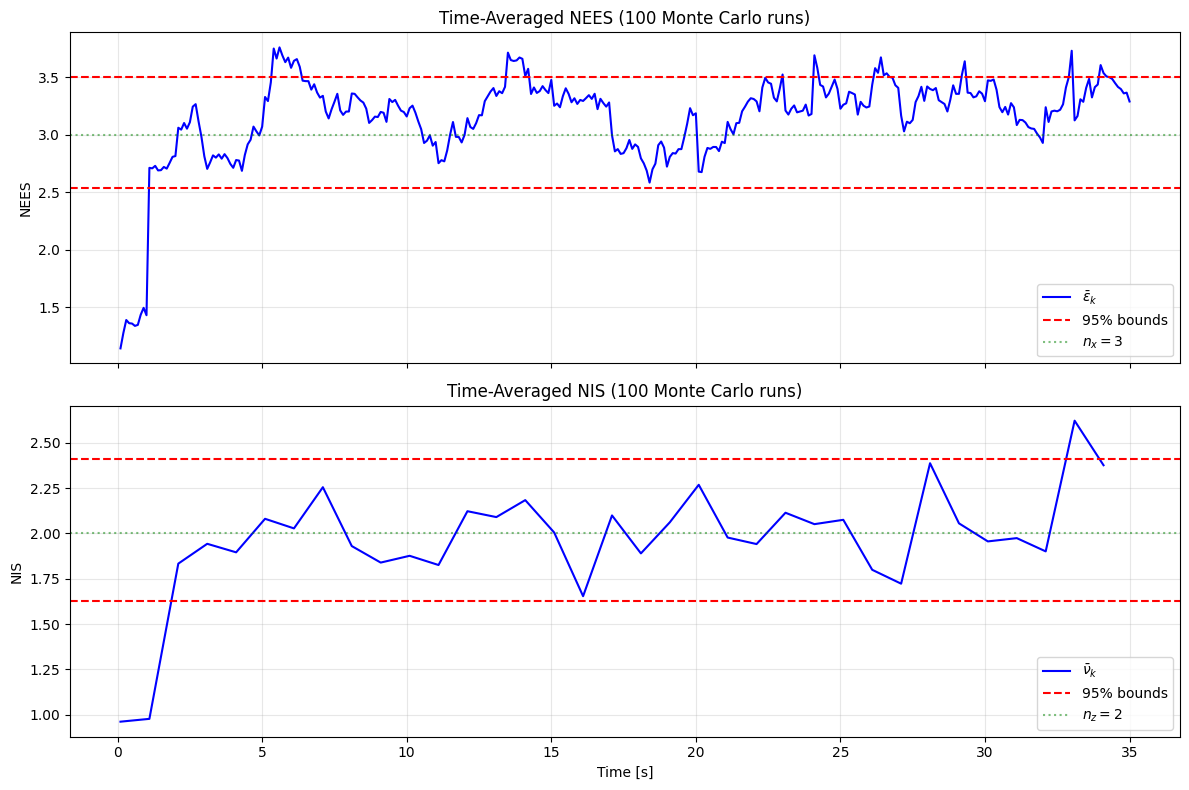

In [129]:
t_vec = np.arange(1, n_steps + 1) * dt

gps_mask = ~np.isnan(nu_bar)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(t_vec, epsilon_bar, color='b', linewidth=1.5, label=r'$\bar{\epsilon}_k$')
ax1.axhline(nees_lo, color='r', linestyle='--', label='95% bounds')
ax1.axhline(nees_hi, color='r', linestyle='--')
ax1.axhline(nx, color='g', linestyle=':', alpha=0.5, label=r'$n_x = 3$')
ax1.set_ylabel('NEES')
ax1.set_title(f'Time-Averaged NEES ({N} Monte Carlo runs)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(t_vec[gps_mask], nu_bar[gps_mask], color='b', linewidth=1.5, label=r'$\bar{\nu}_k$')
ax2.axhline(nis_lo, color='r', linestyle='--', label='95% bounds')
ax2.axhline(nis_hi, color='r', linestyle='--')
ax2.axhline(nz, color='g', linestyle=':', alpha=0.5, label=r'$n_z = 2$')
ax2.set_ylabel('NIS')
ax2.set_xlabel('Time [s]')
ax2.set_title(f'Time-Averaged NIS ({N} Monte Carlo runs)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('NEES_NIS_ESEKF.png', dpi=150)
plt.show()